In [1]:
from geopacha_utilities.model_builder import get_calibrated_dino_model,ArchDetectionModule


/home/VANDERBILT/zimmejr1/anaconda3/envs/DinoV3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-17 13:00:51:rastervision.pipeline.rv_config: WARNING - Root temporary directory cannot be used: /opt/data/tmp. Using root: /tmp/tmp5o7me7q6


In [2]:

repo_path= "/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov2"
model_backbone_name= 'dinov2_vitl14'
lora_config={
                    "r": 30,
                    "lora_alpha": 16,
                    "lora_dropout": 0.1,
                    "target_modules": ["qkv", "proj"]
                }
model_v2 = get_calibrated_dino_model(num_classes=3,
                                    model_name=model_backbone_name,
                                    weights_path='/home/VANDERBILT/zimmejr1/GeoPACHA/7.pt',
                                    repo_path=repo_path,
                                    smoothing=.01,
                                    fine_tune=True,
                                    use_lora=True,
                                    
                                    lora_config=lora_config,
                                    gamma=2)

Loading and adjusting model
No pretrained weights path given. Loading with random weights.
Load weights
Checkpoint loaded from: /home/VANDERBILT/zimmejr1/GeoPACHA/7.pt
  Backbone has PEFT: True
  Keep LoRA adapters: True
  Missing keys: 51
  Unexpected keys: 2
Load Results:
Missing: ['base_model.model.mask_token', 'base_model.model.patch_embed.proj.lora_A.default.weight', 'base_model.model.patch_embed.proj.lora_B.default.weight', 'base_model.model.blocks.0.attn.proj.lora_A.default.weight', 'base_model.model.blocks.0.attn.proj.lora_B.default.weight', 'base_model.model.blocks.1.attn.proj.lora_A.default.weight', 'base_model.model.blocks.1.attn.proj.lora_B.default.weight', 'base_model.model.blocks.2.attn.proj.lora_A.default.weight', 'base_model.model.blocks.2.attn.proj.lora_B.default.weight', 'base_model.model.blocks.3.attn.proj.lora_A.default.weight', 'base_model.model.blocks.3.attn.proj.lora_B.default.weight', 'base_model.model.blocks.4.attn.proj.lora_A.default.weight', 'base_model.model

In [6]:
model_v2.state_dict().keys()

odict_keys(['backbone.backbone_model.cls_token', 'backbone.backbone_model.pos_embed', 'backbone.backbone_model.mask_token', 'backbone.backbone_model.patch_embed.proj.weight', 'backbone.backbone_model.patch_embed.proj.bias', 'backbone.backbone_model.blocks.0.norm1.weight', 'backbone.backbone_model.blocks.0.norm1.bias', 'backbone.backbone_model.blocks.0.attn.qkv.weight', 'backbone.backbone_model.blocks.0.attn.qkv.bias', 'backbone.backbone_model.blocks.0.attn.proj.weight', 'backbone.backbone_model.blocks.0.attn.proj.bias', 'backbone.backbone_model.blocks.0.ls1.gamma', 'backbone.backbone_model.blocks.0.norm2.weight', 'backbone.backbone_model.blocks.0.norm2.bias', 'backbone.backbone_model.blocks.0.mlp.fc1.weight', 'backbone.backbone_model.blocks.0.mlp.fc1.bias', 'backbone.backbone_model.blocks.0.mlp.fc2.weight', 'backbone.backbone_model.blocks.0.mlp.fc2.bias', 'backbone.backbone_model.blocks.0.ls2.gamma', 'backbone.backbone_model.blocks.1.norm1.weight', 'backbone.backbone_model.blocks.1.nor

In [6]:
from geopacha_utilities.model_builder import get_calibrated_dinov3_model,ArchDetectionModule

repo_path= "/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov3"
model_backbone_name= 'dinov3_vitl16'
model_v3 = get_calibrated_dinov3_model(num_classes=3,
                                    model_name=model_backbone_name,
                                    weights_path='/home/VANDERBILT/zimmejr1/Documents/DinoV3_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth',
                                    repo_path=repo_path,
                                    smoothing=.01,
                                    gamma=2)

Loading pretrained backbone weights from:  /home/VANDERBILT/zimmejr1/Documents/DinoV3_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth


In [7]:
import torch
checkpoint = torch.load('/home/VANDERBILT/zimmejr1/GeoPACHA/7.pt',map_location="cpu")
    # 1. Load the checkpoint
state_dict = checkpoint.get("state_dict", checkpoint)


In [8]:
state_dict.keys()

odict_keys(['base_model.model.module.cls_token', 'base_model.model.module.pos_embed', 'base_model.model.module.patch_embed.proj.weight', 'base_model.model.module.patch_embed.proj.bias', 'base_model.model.module.blocks.0.norm1.weight', 'base_model.model.module.blocks.0.norm1.bias', 'base_model.model.module.blocks.0.attn.qkv.base_layer.weight', 'base_model.model.module.blocks.0.attn.qkv.base_layer.bias', 'base_model.model.module.blocks.0.attn.qkv.lora_A.default.weight', 'base_model.model.module.blocks.0.attn.qkv.lora_B.default.weight', 'base_model.model.module.blocks.0.attn.proj.weight', 'base_model.model.module.blocks.0.attn.proj.bias', 'base_model.model.module.blocks.0.ls1.gamma', 'base_model.model.module.blocks.0.norm2.weight', 'base_model.model.module.blocks.0.norm2.bias', 'base_model.model.module.blocks.0.mlp.fc1.weight', 'base_model.model.module.blocks.0.mlp.fc1.bias', 'base_model.model.module.blocks.0.mlp.fc2.weight', 'base_model.model.module.blocks.0.mlp.fc2.bias', 'base_model.mo

In [7]:

# Get module names
modules_v2 = {name for name, _ in model_v2.named_modules()}
modules_v3 = {name for name, _ in model_v3.named_modules()}

print("In V2 but not V3:")
for name in sorted(modules_v2 - modules_v3):
    print(f"  {name}")

print("\nIn V3 but not V2:")
for name in sorted(modules_v3 - modules_v2):
    print(f"  {name}")

In V2 but not V3:
  backbone.backbone_model.blocks.0.drop_path1
  backbone.backbone_model.blocks.0.drop_path2
  backbone.backbone_model.blocks.1.drop_path1
  backbone.backbone_model.blocks.1.drop_path2
  backbone.backbone_model.blocks.10.drop_path1
  backbone.backbone_model.blocks.10.drop_path2
  backbone.backbone_model.blocks.11.drop_path1
  backbone.backbone_model.blocks.11.drop_path2
  backbone.backbone_model.blocks.12.drop_path1
  backbone.backbone_model.blocks.12.drop_path2
  backbone.backbone_model.blocks.13.drop_path1
  backbone.backbone_model.blocks.13.drop_path2
  backbone.backbone_model.blocks.14.drop_path1
  backbone.backbone_model.blocks.14.drop_path2
  backbone.backbone_model.blocks.15.drop_path1
  backbone.backbone_model.blocks.15.drop_path2
  backbone.backbone_model.blocks.16.drop_path1
  backbone.backbone_model.blocks.16.drop_path2
  backbone.backbone_model.blocks.17.drop_path1
  backbone.backbone_model.blocks.17.drop_path2
  backbone.backbone_model.blocks.18.drop_path1

In [22]:
import torch
import torch.nn as nn

# 1. Define the new number of input channels
new_in_channels = 8

# 2. Access the original projection layer to get its configuration
# Path: model.backbone.backbone_model.patch_embed.proj
old_proj = model.backbone.backbone_model.patch_embed.proj

# 3. Create the new Conv2d layer
# We keep kernel_size, stride, and out_channels (1024) the same
new_proj = nn.Conv2d(
    in_channels=new_in_channels,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding
)

# 4. Replace the layer in the model
model.backbone.backbone_model.patch_embed.proj = new_proj



In [16]:
import torch
checkpoint = torch.load("/mnt/sarl_commons06/Wernke_projects/zimmejr1/7.pt",map_location="cpu")

In [23]:
import torch

# 1. Load the checkpoint
state_dict = checkpoint.get("state_dict", checkpoint)

# 2. Define the mess we want to clean up
prefix_to_strip = "base_model.model.module."

cleaned_state_dict = {}

for key, value in state_dict.items():
    # Remove the DDP/PEFT prefix
    new_key = key.replace(prefix_to_strip, "")
    
    # Handle the LoRA specific naming: 
    # LoRA moves the original weights to 'base_layer'
    if ".base_layer" in new_key:
        new_key = new_key.replace(".base_layer", "")
    
    # Skip the actual LoRA adapters (lora_A, lora_B) 
    # unless you have LoRA layers initialized in your current model
    if "lora_" in new_key:
        continue
        
    cleaned_state_dict[new_key] = value

# 3. Load into the backbone
# Note: Since your error log showed the keys starting at 'cls_token', 
# you should load directly into the 'backbone_model'
msg = model.backbone.backbone_model.load_state_dict(cleaned_state_dict, strict=False)

print(f"Load Results:\nMissing: {msg.missing_keys}\nUnexpected: {msg.unexpected_keys}")

Load Results:
Missing: ['mask_token']
Unexpected: ['head.weight', 'head.bias']


In [21]:
cleaned_state_dict.get('patch_embed.proj.weight').shape

torch.Size([1024, 8, 14, 14])

In [15]:
state_dict.get("patch_embed.proj.weight").shape

torch.Size([1024, 3, 14, 14])

In [7]:
import torch
import torch.nn as nn

# 1. Define the new number of input channels
new_in_channels = 8

# 2. Access the original projection layer to get its configuration
# Path: model.backbone.backbone_model.patch_embed.proj
old_proj = model.backbone.backbone_model.patch_embed.proj

# 3. Create the new Conv2d layer
# We keep kernel_size, stride, and out_channels (1024) the same
new_proj = nn.Conv2d(
    in_channels=new_in_channels,
    out_channels=old_proj.out_channels,
    kernel_size=old_proj.kernel_size,
    stride=old_proj.stride,
    padding=old_proj.padding
)

# 4. Replace the layer in the model
model.backbone.backbone_model.patch_embed.proj = new_proj

In [8]:
model

RetinaNet(
  (backbone): Dinov3Backbone(
    (backbone_model): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(8, 1024, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-23): 24 x NestedTensorBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (drop): Dropout(p

In [ ]:
model.transform = 

GeneralizedRCNNTransform(
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    Resize(min_size=(640,), max_size=640, mode='bilinear')
)

In [ ]:
import torch
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.ops import sigmoid_focal_loss
from src.detection.model import dinov3_detection
repo_path = "/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov3"
weights_path = "/home/VANDERBILT/zimmejr1/Documents/DinoV3_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
model_name  = "dinov3_vitl16"


def _sum(x):
    res = x[0]
    for i in x[1:]:
        res = res + i
    return res
# 1. Define the custom loss logic inside a subclass of the Head
class CalibratedRetinaNetHead(torch.nn.Module):
    def __init__(self, original_head, smoothing, gamma):
        super().__init__()
        self.original_head = original_head
        self.smoothing = smoothing
        self.gamma = gamma

        # This is to fix using det_utils.Matcher.BETWEEN_THRESHOLDS in TorchScript.
        # TorchScript doesn't support class attributes.
        # https://github.com/pytorch/vision/pull/1697#issuecomment-630255584
        self.BETWEEN_THRESHOLDS = -2

    def forward(self, x):
        return self.original_head(x)

    
    def compute_loss(self, targets, head_outputs, matched_idxs):
        losses = []

        cls_logits = head_outputs["cls_logits"]

        for targets_per_image, cls_logits_per_image, matched_idxs_per_image in zip(targets, cls_logits, matched_idxs):
            # determine only the foreground
            foreground_idxs_per_image = matched_idxs_per_image >= 0
            num_foreground = foreground_idxs_per_image.sum()

            # create the target classification
            gt_classes_target = torch.zeros_like(cls_logits_per_image)
            gt_classes_target[
                foreground_idxs_per_image,
                targets_per_image["labels"][matched_idxs_per_image[foreground_idxs_per_image]],
            ] = 1.0

            # --- Apply Label Smoothing ---
            # Formula: target = target * (1 - smoothing) + 0.5 * smoothing
            # This pushes 0.0 to epsilon and 1.0 to 1-epsilon
            if hasattr(self, 'smoothing') and self.smoothing > 0:
                gt_classes_target = gt_classes_target * (1 - self.smoothing) + 0.5 * self.smoothing

            # find indices for which anchors should be ignored
            valid_idxs_per_image = matched_idxs_per_image != self.BETWEEN_THRESHOLDS

            # compute the classification loss
            losses.append(
                sigmoid_focal_loss(
                    cls_logits_per_image[valid_idxs_per_image],
                    gt_classes_target[valid_idxs_per_image],
                    reduction="sum",
                    gamma=self.gamma
                )
                / max(1, num_foreground)
            )

        return _sum(losses) / len(targets)

    # def compute_loss(self, targets, head_outputs, matched_idxs):
    #     total_loss = 0.0
    #     total_num_foreground = 0

    #     cls_logits = head_outputs['cls_logits']

    #     for targets_per_image, cls_logits_per_image, matched_idxs_per_image in zip(targets, cls_logits, matched_idxs):
    #         gt_classes_target = torch.zeros_like(cls_logits_per_image)
    #         foreground_idxs = matched_idxs_per_image >= 0
            
    #         if foreground_idxs.any():
    #             gt_classes_target[foreground_idxs, targets_per_image['labels'][matched_idxs_per_image[foreground_idxs]]] = 1.0

    #         # Apply Label Smoothing
    #         gt_classes_target = gt_classes_target * (1 - self.smoothing) + 0.5 * self.smoothing
            
    #         valid_idxs = matched_idxs_per_image != -1 
            
    #         # Compute loss (keep as sum)
    #         loss = sigmoid_focal_loss(
    #             cls_logits_per_image[valid_idxs], 
    #             gt_classes_target[valid_idxs], 
    #             reduction='sum',
    #             gamma=self.gamma
    #         )
            
    #         total_loss += loss
    #         total_num_foreground += foreground_idxs.sum().item()

    #     # Normalize by the total number of foreground anchors across the batch
    #     return total_loss / max(1, total_num_foreground)
    
# 2. Function to "Patch" your model for Raster Vision
def get_calibrated_dinov3_model(num_classes, smoothing, gamma):
    # This is where you'd initialize your DINOv3 + RetinaNet model
    model = dinov3_detection(
        fine_tune=True,
        num_classes=2, 
        weights=weights_path,
        model_name=model_name,
        repo_dir=repo_path,
        feature_extractor="multi",
        head="retinanet"
    ) 
    
    # Wrap the existing classification head with our calibrated version
    original_head = model.head.classification_head
    model.head.classification_head = CalibratedRetinaNetHead(
        original_head, 
        smoothing=smoothing, 
        gamma=gamma
    )
    return model

In [ ]:
from src.detection.model import dinov3_detection
# repo_path = "/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov3"
# weights_path = "/home/VANDERBILT/zimmejr1/Documents/DinoV3_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
# model_name  = "dinov3_vitl16"
# model = dinov3_detection(
#     fine_tune=True,
#     num_classes=2, 
#     weights=weights_path,
#     model_name=model_name,
#     repo_dir=repo_path,
#     feature_extractor="multi",
#     head="retinanet"
# )
model = get_calibrated_dinov3_model(num_classes=2,smoothing=0.01,gamma=2.5)
from rastervision.pytorch_learner.object_detection_utils import TorchVisionODAdapter
model = TorchVisionODAdapter(model)

In [ ]:

# model.model.head.classification_head.loss_function

In [1]:
import os
import geopandas as gpd

import pathlib

from rastervision.core.data import GeoJSONVectorSource, RasterioCRSTransformer,ClassConfig
from rastervision.pytorch_learner import ClassificationSlidingWindowGeoDataset
from rastervision.core.data import RasterioSource
from geopacha_utilities.utilities import find_pixel_size
TRAINING_AOI_DIRECTORY = '/mnt/sarl_commons06/Wernke_projects/zimmejr1/DinoV3_Chacu_AOI_12_23_25/training_aoi'
VALIDATION_AOI_DIRECTORY = '/mnt/sarl_commons06/Wernke_projects/zimmejr1/DinoV3_Chacu_AOI_12_23_25/validation_aoi_sampled'
LABEL_URI = '/mnt/sarl_commons06/Wernke_projects/zimmejr1/DinoV3_Chacu_AOI_12_23_25/chacu_labels.geojson'
IMAGERY_BASE_DIRECTORY = '/mnt/sarl_commons06/Wernke_projects/GeoPACHA/Imagery_Machine_Learning/Analysis_Images'

patch_dim = 1024

2026-03-17 11:44:52:rastervision.pipeline.rv_config: WARNING - Root temporary directory cannot be used: /opt/data/tmp. Using root: /tmp/tmp1zzy3gnc
/home/VANDERBILT/zimmejr1/anaconda3/envs/DinoV3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import albumentations as A

data_augmentation_transform = A.Compose([
    A.D4(p=1.0),
    # A.OneOf([
    #     A.HueSaturationValue(hue_shift_limit=10),
    #     A.RGBShift(),
    #     A.ToGray(),
    #     A.ToSepia(),
    #     A.RandomBrightnessContrast(),
    #     A.RandomGamma(),
    # ]),
    # A.CoarseDropout(max_height=32, max_width=32, max_holes=5)
])

In [ ]:


class_config = ClassConfig(
    names=['chacu', 'background'],
    colors=['darkred', 'gray'],
    null_class='background')



    

In [4]:
from tqdm import tqdm
from rastervision.pytorch_learner import ObjectDetectionRandomWindowGeoDataset,ObjectDetectionSlidingWindowGeoDataset
from rastervision.pytorch_learner.object_detection_utils import collate_fn as od_collate
from rastervision.core.data import ObjectDetectionLabelSourceConfig
from rastervision.core.data import ObjectDetectionLabelSource

class_config = ClassConfig(
    names=['chacu', 'background'],
    colors=['darkred', 'gray'],
    null_class='background')



training_dataset_list = []
val_dataset_list = []
# for aoi_path in tqdm(os.listdir(TRAINING_AOI_DIRECTORY),desc="making datasets"):
#         full_aoi_path = os.path.join(TRAINING_AOI_DIRECTORY,aoi_path)
#         aoi = gpd.read_file(full_aoi_path)
#         image_id = aoi['imageid'][0]
#         # print(image_id)
#         image_path  = pathlib.PureWindowsPath(aoi['filepath'][0]).as_posix()
#         full_image_path = os.path.join(IMAGERY_BASE_DIRECTORY,image_path)

#         #Adjust the patch size to account for different resolution
#         rasterSource = RasterioSource(
#                 full_image_path, #path to the image
#                 allow_streaming=True, # allow_streaming so we don't have to load the whole image
#             ) 
#         pixel_size = find_pixel_size(rasterSource.imagery_path)
#         size = round(patch_dim*.5/pixel_size)



#         # print("CREATING DATASET")
#         try:
#             ds = ObjectDetectionRandomWindowGeoDataset.from_uris(
#                 image_uri=full_image_path,
#                 aoi_uri=full_aoi_path,
#                 label_vector_uri = LABEL_URI,
#                 class_config=class_config,
#                 image_raster_source_kw=dict(allow_streaming=True,channel_order=[4,2,1]),
#                 max_windows=4,
#                 size_lims = [size,size+1],
#                 out_size=patch_dim,within_aoi=True,ioa_thresh = 0.75,neg_ratio=.5,
#                 transform = data_augmentation_transform
#             )
#             ds.scene.id=image_id
#             training_dataset_list.append(ds)
#         except:
#             try:
#                 # print("Extracting Negatives")
#                 ds = ObjectDetectionRandomWindowGeoDataset.from_uris(
#                     image_uri=full_image_path,
#                     aoi_uri=full_aoi_path,
#                     label_vector_uri = LABEL_URI,
#                     class_config=class_config,
#                     image_raster_source_kw=dict(allow_streaming=True,channel_order=[4,2,1]),
#                     max_windows=2,
#                     size_lims = [size,size+1],
#                     out_size=patch_dim,within_aoi=False,
#                     transform = data_augmentation_transform
#                 )
#                 ds.scene.id=image_id
#                 training_dataset_list.append(ds)
#             except Exception as e: 
#                 print(f"Couldn't create dataset because:\n{e}")                   
#                 continue
print("MAKING VALIDATION DATA")
for aoi_path in tqdm(os.listdir(VALIDATION_AOI_DIRECTORY),desc="making datasets"):
        full_aoi_path = os.path.join(VALIDATION_AOI_DIRECTORY,aoi_path)
        aoi = gpd.read_file(full_aoi_path)
        image_id = aoi['imageid'][0]
        # print(image_id)
        image_path  = pathlib.PureWindowsPath(aoi['filepath'][0]).as_posix()
        full_image_path = os.path.join(IMAGERY_BASE_DIRECTORY,image_path)

        #Adjust the patch size to account for different resolution
        rasterSource = RasterioSource(
                full_image_path, #path to the image
                allow_streaming=True, # allow_streaming so we don't have to load the whole image
            ) 
        pixel_size = find_pixel_size(rasterSource.imagery_path)
        size = round(patch_dim*.5/pixel_size)


        try:
              ds = ObjectDetectionSlidingWindowGeoDataset.from_uris(
                    image_uri = full_image_path,
                    aoi_uri = full_aoi_path,
                    label_vector_uri = LABEL_URI,
                    class_config = class_config,
                    size = size,
                    stride = int(size*0.5),
                    out_size = patch_dim,within_aoi=True,
                    image_raster_source_kw=dict(allow_streaming=True,channel_order=[4,2,1]),return_window=False

              )
              ds.scene.id = image_id
              val_dataset_list.append(ds)
        except Exception as e:
              print(f"Problem with {image_id} sliding window: \n {e}")
              continue

MAKING VALIDATION DATA


making datasets: 100%|██████████| 6/6 [00:08<00:00,  1.40s/it]


In [7]:
val_dataset_list[0].size[0]

1025

In [ ]:
from torch.utils.data import ConcatDataset
training_data = ConcatDataset(training_dataset_list)
validation_data = ConcatDataset(val_dataset_list)

In [ ]:
# from torch.utils.data import DataLoader
# train_dl = DataLoader(
#     training_data,
#     batch_size=8,
#     # This is the collate function needed for PyTorch object detection models
#     collate_fn=od_collate, 
#     # Must be 0 workers to bypass the multiprocessing error
#     num_workers=0, 
#     shuffle=True
# )

# for batch_idx, (images, targets) in enumerate(train_dl):
#     print(f"Testing Batch {batch_idx + 1}/{len(train_dl)}...")
#     print(len(targets))
#     print(any([len(target.get_field("class_ids")) for target in targets]))

In [ ]:
len(training_data)

In [ ]:
from rastervision.pytorch_learner import ObjectDetectionGeoDataConfig,ObjectDetectionLearnerConfig
from rastervision.pytorch_learner import SolverConfig
data_cfg = ObjectDetectionGeoDataConfig(
    class_config = class_config,
    num_workers=0
)

solver_cfg = SolverConfig(
    batch_sz = 8,
    lr = 5e-5,

    # lr = 1.5*5e-5,
)

learner_cfg = ObjectDetectionLearnerConfig(data=data_cfg,solver=solver_cfg)



In [ ]:
import os

# Set to '0' to use the first GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0' 

# OR
# Set to '' to use CPU-only (if you want to completely disable GPU access)
# os.environ['CUDA_VISIBLE_DEVICES'] = '' 

print(f"CUDA_VISIBLE_DEVICES is set to: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
from rastervision.pytorch_learner import ObjectDetectionLearner
learner = ObjectDetectionLearner(
    cfg = learner_cfg,
    output_dir = 'data',
    model=model,
    train_ds = training_data,
    valid_ds = validation_data
)

In [ ]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# Rerun the training after setting this
learner.train(epochs=70)

In [ ]:
learner

In [ ]:
learner.log_data_stats()

In [ ]:
%load_ext tensorboard
%tensorboard --bind_all --logdir "data/train-demo/tb-logs" --reload_interval 10

In [ ]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# Rerun the training after setting this
# learner.train(epochs=10)

In [ ]:
# Initialize model
from src.detection.model import dinov3_detection
repo_path = "/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov3"
weights_path = "/home/VANDERBILT/zimmejr1/Documents/DinoV3_weights/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
model_name  = "dinov3_vitl16"
model = dinov3_detection(
    fine_tune=True,
    num_classes=2, 
    weights=weights_path,
    model_name=model_name,
    repo_dir=repo_path,
    feature_extractor="multi",
    head="retinanet"
)
model = TorchVisionODAdapter(model)

model.load_state_dict(torch.load("data/train-chacu-round3/last-model.pth"))

In [ ]:
(os.listdir(AOI_DIRECTORY))[0]

In [ ]:
from rastervision.core.data import ObjectDetectionLabels
AOI_DIRECTORY = "/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov3-james-experiments/OD_data/Buffered_Chacu_AOI/ExpandedSecondPass"
# val_dataset_list = []
for aoi_path in [(os.listdir(AOI_DIRECTORY))[0]]:
      print("Making dataset")
      full_aoi_path = os.path.join(AOI_DIRECTORY,aoi_path)
      aoi = gpd.read_file(full_aoi_path)
      image_id_aoi = aoi['imageid'][0]
      image_id = image_id_aoi.split('_')[0]
      output_path = os.path.join('/home/VANDERBILT/zimmejr1/Documents/GitHub/dinov3_stack/data/train-chacu-round3/predictions2',f"{image_id}_chacu_labels.geojson")
      print(image_id)

      if os.path.exists(output_path): continue
      image_path  = pathlib.PureWindowsPath(aoi['filepath'][0]).as_posix()
      full_image_path = os.path.join(IMAGERY_BASE_DIRECTORY,image_path)

      try:
            #Adjust the patch size to account for different resolution
        rasterSource = RasterioSource(
        full_image_path, #path to the image
        allow_streaming=True, # allow_streaming so we don't have to load the whole image
        ) 
        pixel_size = find_pixel_size(rasterSource.imagery_path)
        size = round(patch_dim*.5/pixel_size)
        ds = ObjectDetectionSlidingWindowGeoDataset.from_uris(
              image_uri = full_image_path,
              # aoi_uri = full_aoi_path,
              # label_vector_uri = LABEL_URI,
              class_config = class_config,
              size = size,
              stride = int(size/2),
              out_size = patch_dim,
              image_raster_source_kw=dict(allow_streaming=True,channel_order=[4,2,1]),return_window=False

              )
        ds.scene.id = image_id
        predictions = learner.predict_dataset(
          ds,
          raw_out=True,
          numpy_out=True,
          progress_bar=True,
          dataloader_kw = {'num_workers':16,'batch_size':8})

        pred_labels = ObjectDetectionLabels.from_predictions(
          ds.windows,
          predictions,
          )
        pred_labels_2 = pred_labels.prune_duplicates(pred_labels,score_thresh=.1,merge_thresh=.1)
        pred_labels_2.save(output_path,class_config=class_config,crs_transformer=ds.scene.raster_source.crs_transformer)
      except Exception as e:
          print(f"Skipping {image_id} because of : {e} ")
          continue
          


In [ ]:
learner.save_model_bundle()

In [ ]:

for ds in val_dataset_list:

    ds = val_dataset_list[2]
    

In [ ]:
from rastervision.core.data import ObjectDetectionLabels

ds = val_dataset_list[2]
predictions = learner.predict_dataset(
    ds,
    raw_out=True,
    numpy_out=True,
    progress_bar=True)

pred_labels = ObjectDetectionLabels.from_predictions(
    ds.windows,
    predictions,
    )

In [ ]:
pred_labels.save("test_pred_labels.geojson",class_config=class_config,crs_transformer=ds.scene.raster_source.crs_transformer)

In [ ]:
pred_labels_2 = pred_labels.prune_duplicates(pred_labels,score_thresh=.3,merge_thresh=.8)

In [ ]:
pred_labels_2.save("test_pred_labels2.geojson",class_config=class_config,crs_transformer=ds.scene.raster_source.crs_transformer)

In [ ]:
test_labels= ObjectDetectionLabels.from_predictions(validation_data.datasets[0].windows,test)

In [ ]:
test_labels.get_boxes()

In [ ]:
valid_dl = learner.get_dataloader('valid')
preds = learner.predict_dataloader(
            valid_dl, return_format='xyz', batched_output=True, raw_out=True)

In [ ]:
x,y,z = next(preds)

In [ ]:
x.shape

In [ ]:
from os.path import join

import matplotlib.pyplot as plt
import torch

from rastervision.pytorch_learner.dataset import (
    SemanticSegmentationSlidingWindowGeoDataset,
    ObjectDetectionSlidingWindowGeoDataset,
    ClassificationSlidingWindowGeoDataset)
from rastervision.pytorch_learner.dataset.visualizer import (
    SemanticSegmentationVisualizer,
    ObjectDetectionVisualizer,
    ClassificationVisualizer)
from rastervision.core.data import ClassConfig
# channel_display_groups = {'RGB': (4, 2, 1)}
vis = ObjectDetectionVisualizer(
    class_names=class_config.names, class_colors=class_config.colors)

filtered_outputs = [img_pred.score_filter(score_thresh=.3) for img_pred in z]
vis.plot_batch(x,z=filtered_outputs, show=True)

In [ ]:
for img_pred in z:
    img_pred.score_filter()

In [ ]:
model

In [ ]:
import rastervision.pytorch_learner as rv_plt
print([item for item in dir(rv_plt) if 'Dataset' in item])

In [ ]:
from rastervision.pytorch_learner import (
    ObjectDetectionGeoDataConfig, 
    ObjectDetectionLearnerConfig,
)

# 1. Initialize the GeoDatasetConfig (can be empty for inference)

# 2. Update your data_cfg
data_cfg = ObjectDetectionGeoDataConfig(
    class_config=class_config,
    train_scenes=[],# This satisfies the internal check
    num_workers=0
)

# 3. Recreate the learner config
learner_cfg = ObjectDetectionLearnerConfig(data=data_cfg, solver=solver_cfg)

# 4. Initialize Learner and load weights
learner = ObjectDetectionLearner(
    cfg=learner_cfg,
    output_dir='data',
    model=model 
)
learner.load_state_dict('data/model.pth')

In [ ]:
from rastervision.pytorch_learner import ObjectDetectionLearner
os.environ['CUDA_VISIBLE_DEVICES'] = '0' 



# 2. Instantiate the learner
# Note: 'model' should be the same architecture instance used before
learner = ObjectDetectionLearner(
    cfg=learner_cfg,
    output_dir='data',
    model=model 
)

# 3. Load the saved weights
# Replace 'model.pth' with your actual filename
learner.load_state_dict('data/model.pth')

In [ ]:
learner.plot_predictions(split='valid', show=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your spreadsheet
df = pd.read_csv('/home/VANDERBILT/zimmejr1/Desktop/reliability_plot_csv_partial.csv') 
num_bins=11
# 2. Define the bins (e.g., 10 bins from 0 to 1)
bins = np.linspace(0.5, 1, num_bins)
df['bin'] = pd.cut(df['score'], bins=bins, include_lowest=True)

# 3. Calculate accuracy (mean of is_chacu) per bin
# Since is_chacu is boolean, its mean is the frequency of True values
calibration = df.groupby('bin')['is_chacu'].mean().reset_index()

# 4. Get the center of each bin for the x-axis
calibration['bin_center'] = calibration['bin'].apply(lambda x: x.mid)

bar_width = (0.5 / num_bins) * 0.9
# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.bar(calibration['bin_center'], calibration['is_chacu'], width=bar_width, alpha=0.7, edgecolor='black')

# Add a diagonal line representing "Perfect Calibration"
plt.plot([0.5, 1], [0.5, 1], linestyle='--', color='red', label='Perfectly Calibrated')

plt.xlabel('Model Confidence Score')
plt.ylabel('Accuracy (Frequency of Correct Prediction)')
plt.title('Model Calibration Plot')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def calculate_ece(df, score_col='score', target_col='is_chacu', n_bins=10):
    # 1. Convert boolean to 1/0 if necessary
    y_true = df[target_col].astype(int).values
    y_prob = df[score_col].values
    
    # 2. Define bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    
    # 3. Calculate error for each bin
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Find samples that fall into this confidence bin
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin) # This is |Bm| / n
        
        if prop_in_bin > 0:
            # Actual accuracy in this bin
            accuracy_in_bin = np.mean(y_true[in_bin])
            # Average confidence in this bin
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            
            # Weighted absolute difference
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
    return ece

# Usage:
# df = pd.read_csv("your_file.csv") # or pd.read_excel(...)
ece_value = calculate_ece(df, score_col='score', target_col='is_chacu')

print(f"Expected Calibration Error: {ece_value:.4f}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.isotonic import IsotonicRegression

# 1. Load your data
# df = pd.read_csv("your_data.csv")

# 2. Prepare data (Isotonic Regression needs X as scores and y as 0/1)
X = df['score'].values
y = df['is_chacu'].astype(int).values

# 3. Fit the calibrator
# This learns the mapping to fix that 0.17 error
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(X, y)

# 4. Generate new, calibrated scores
df['calibrated_score'] = iso_reg.predict(X)

# Now, if you recalculate ECE on 'calibrated_score', 
# it should be significantly lower (likely < 0.05).
df.to_csv("calibrated_results.csv", index=False)

In [ ]:
calculate_ece(df,score_col='calibrated_score',target_col='is_chacu')

In [57]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

def tb_logs_to_df(root_dir):
    all_data = []

    # Walk through the directory and subdirectories
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if "tfevents" in file:
                path = os.path.join(root, file)
                
                # Initialize the EventAccumulator
                # size_guidance limits how many events are loaded into RAM
                ea = event_accumulator.EventAccumulator(path, size_guidance={
                    event_accumulator.SCALARS: 0,  # 0 means load all
                })
                ea.Reload()

                # Get the name of the subdirectory as a 'run' identifier
                run_name = os.path.basename(root)

                # Extract Scalar data
                tags = ea.Tags()['scalars']
                for tag in tags:
                    events = ea.Scalars(tag)
                    for event in events:
                        all_data.append({
                            'run': run_name,
                            'step': event.step,
                            'wall_time': event.wall_time,
                            'metric': tag,
                            'value': event.value
                        })

    return pd.DataFrame(all_data)



In [34]:
df = tb_logs_to_df('logs/geopacha_object_detection')
df

,run,step,wall_time,metric,value
0,dinov3_vitl16ots_upsample_peft,0,1.776458e+09,mAP50,0.322619
1,dinov3_vitl16ots_upsample_peft,1,1.776463e+09,mAP50,0.282532
2,dinov3_vitl16ots_upsample_peft,2,1.776468e+09,mAP50,0.286882
3,dinov3_vitl16ots_upsample_peft,3,1.776473e+09,mAP50,0.323796
4,dinov3_vitl16ots_upsample_peft,4,1.776478e+09,mAP50,0.336559
...,...,...,...,...,...
1038,dinov2_vitl14_test_ots,3681,1.776416e+09,epoch,13.000000
1039,dinov2_vitl14_test_ots,3944,1.776420e+09,epoch,14.000000
1040,dinov2_vitl14_test_ots,4207,1.776424e+09,epoch,15.000000
1041,dinov2_vitl14_test_ots,4470,1.776428e+09,epoch,16.000000


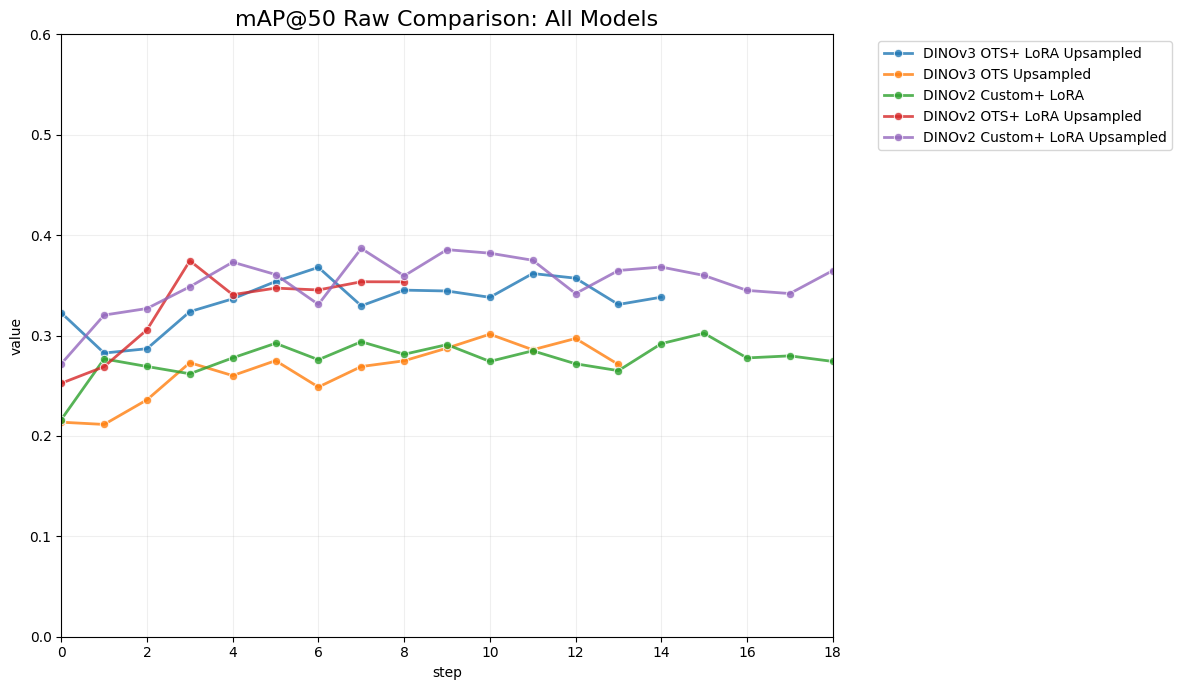

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the Categories
def get_master_label(run_name):
    run_name = run_name.lower()
    arch = "DINOv3" if "v3" in run_name else "DINOv2"
    
    # Simple logic: Is it Custom or Off-the-Shelf? Is it PEFT?
    is_custom = ("custom" in run_name or "ots" not in run_name) and arch != "DINOv3"
    is_peft = "peft" in run_name or "lora" in run_name
    
    tag = "Custom" if is_custom else "Off-the-Shelf"
    peft_tag = "+ LoRA" if is_peft else ""

    is_upsample = "upsample" in run_name
    upsample_tag = "Upsampled" if is_upsample else ""
    
    return f"{arch} {tag}{peft_tag} {upsample_tag}"

# 2. Filter and Label
# Ensure we only have map50 and exclude specific strings you mentioned
master_df = df[df['metric'].str.contains('map50', case=False)].copy()
# master_df = master_df[master_df['run']!="dinov2_vitl14_peft"]
master_df = master_df[~master_df['run'].str.contains('validclip|lr4e4|small|test', case=False)].copy()
master_df['Label'] = master_df['run'].apply(get_master_label)

# 3. Basic Plot
plt.figure(figsize=(12, 7))

# We use 'units' to ensure every run stays as its own line 
# but shares a color based on its 'Label'
sns.lineplot(
    data=master_df, 
    x='step', 
    y='value', 
    hue='Label', 
    units='run',        # Keeps lines separate (no averaging)
    estimator=None,     # Disables the mean line
    alpha=0.8,          # Keeps them visible
    linewidth=2,
    marker='o' ,
)
plt.xlim(0,18)  
plt.ylim(0,.6)


plt.title("mAP@50 Raw Comparison: All Models", fontsize=16)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [126]:
master_df['run'].unique()

array(['dinov3_vitl16ots_upsample_peft', 'dinov3_vitl16_upsample2',
       'dinov2_vitl14_peft', 'dinov2_vitl14ots_upsample_peft',
       'dinov2_vitl16_upsample_peft'], dtype=object)

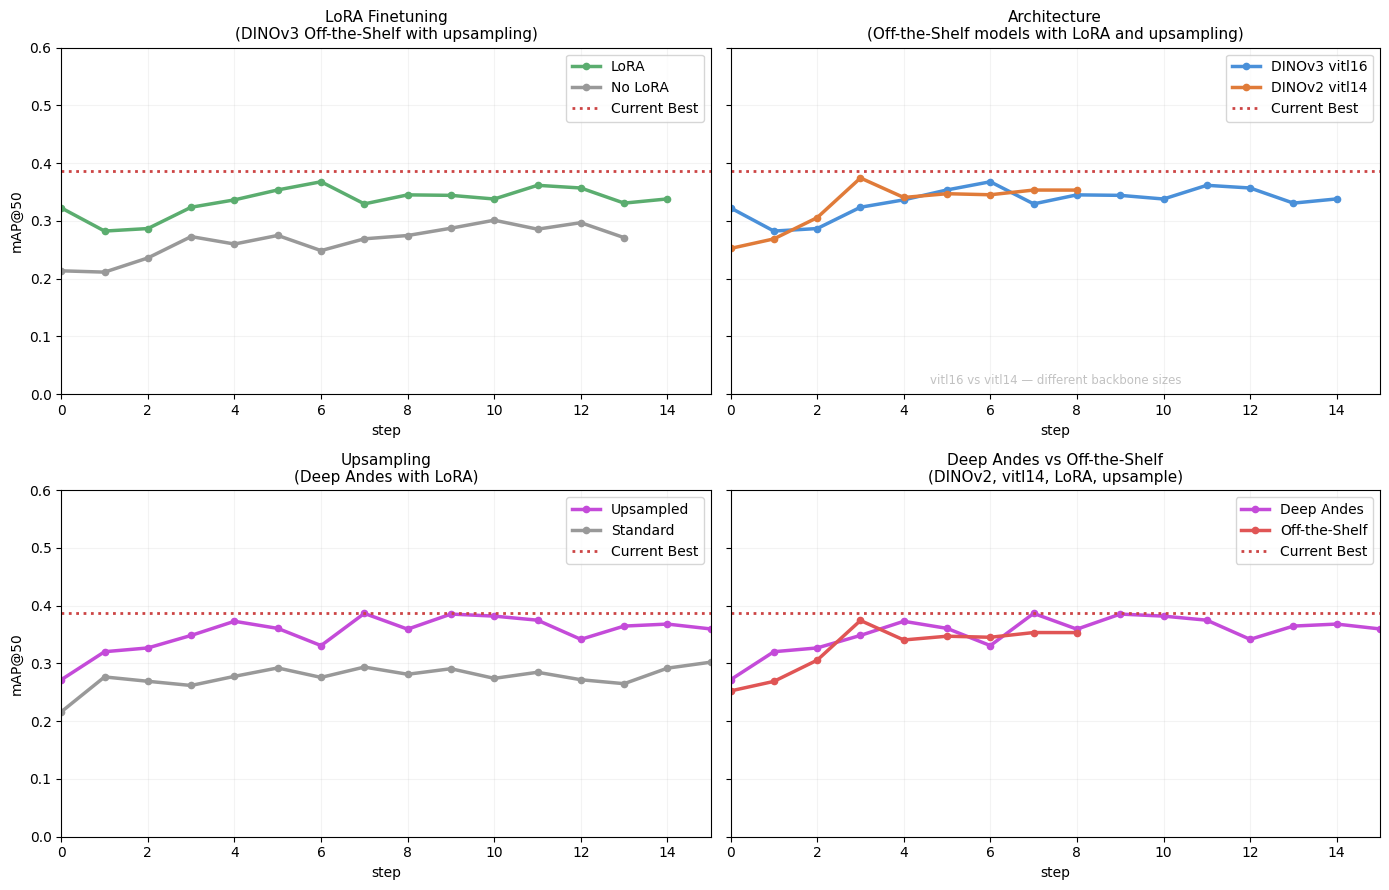

In [170]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np



PANELS = [
            {
        "title": "LoRA Finetuning\n(DINOv3 Off-the-Shelf with upsampling)",
        "note": None,
        "pairs": [
            ("LoRA",  "dinov3_vitl16ots_upsample_peft", "#5BAD6F"),
            ("No LoRA", "dinov3_vitl16_upsample2",         "#999999"),
        ],
    },
    {
        "title": "Architecture\n(Off-the-Shelf models with LoRA and upsampling)",
        "note": "vitl16 vs vitl14 — different backbone sizes",
        "pairs": [
            ("DINOv3 vitl16", "dinov3_vitl16ots_upsample_peft",  "#4A90D9"),
            ("DINOv2 vitl14", "dinov2_vitl14ots_upsample_peft",  "#E07B39"),
        ],
    },
        {
        "title": "Upsampling\n(Deep Andes with LoRA)",
        "note": None,
        "pairs": [
            ("Upsampled", "dinov2_vitl16_upsample_peft", "#C44BD9"),
            ("Standard",  "dinov2_vitl14_peft",           "#999999"),
        ],
    },
    {
        "title": "Deep Andes vs Off-the-Shelf\n(DINOv2, vitl14, LoRA, upsample)",
        "note": None,
        "pairs": [
            ("Deep Andes", "dinov2_vitl16_upsample_peft",    "#C44BD9"),
            ("Off-the-Shelf",    "dinov2_vitl14ots_upsample_peft", "#E05555"),
        ],
    },



    
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
# fig.suptitle("mAP@50: Isolating Each Factor", fontsize=14, y=1.02)

for ax, panel in zip(axes.flatten(), PANELS):
    for label, run_name, color in panel["pairs"]:
        run_df = master_df[master_df["run"] == run_name].sort_values("step")
        ax.plot(run_df["step"], run_df["value"],
                color=color, linewidth=2.5,
                marker="o", markersize=4.5,
                label=label)
                

    ax.set_title(panel["title"], fontsize=11)
    if panel["note"]:
        ax.text(0.5, 0.03, panel["note"],
                transform=ax.transAxes, fontsize=8.5,
                color="#9999", ha="center")
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 0.6)
    ax.grid(True, alpha=0.15)
    ax.set_xlabel("step")
    ax.axhline(y=0.387, color='#cc4444', ls=':', lw=2, alpha=1, label='Current Best')
    # ax.text(.93, 0.4, f'{0.387}', 
    #         transform=ax.get_yaxis_transform(), 
    #         va='center', ha='left', 
    #         fontsize=9, color='#cc4444', fontweight='bold')
    ax.legend(fontsize=10),



axes[0, 0].set_ylabel("mAP@50")
axes[1, 0].set_ylabel("mAP@50")
plt.tight_layout()
plt.savefig("map50_matched_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2848161/3961515828.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_map['Model'] = df_map['run'].apply(lambda x: 'DINOv3' if 'v3' in x.lower() else 'DINOv2')


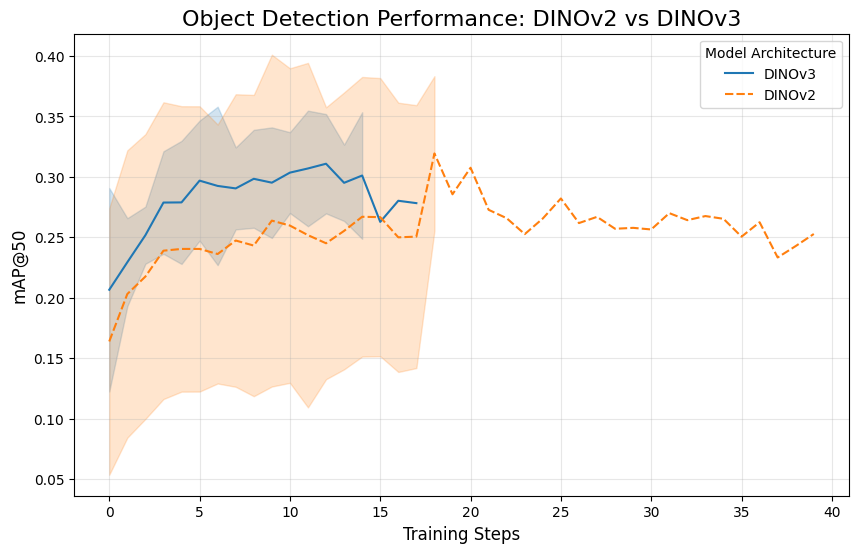

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


# Filter for map50 metric
df_map = df[df['metric'].str.contains('map50', case=False)]


# Create a 'Model' column based on the run folder names
df_map['Model'] = df_map['run'].apply(lambda x: 'DINOv3' if 'v3' in x.lower() else 'DINOv2')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_map, x='step', y='value', hue='Model', style='Model', 
             errorbar='sd') # 'sd' shows standard deviation bands

plt.title('Object Detection Performance: DINOv2 vs DINOv3', fontsize=16)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('mAP@50', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Model Architecture')
plt.show()

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the max mAP50 for each run (the peak performance)
final_stats = df_map.groupby('run').agg({
    'value': 'max',
    'Model': 'first',
    'Upsample': 'first', # You'll need to tag these in your DF
    'PEFT': 'first'
}).reset_index()

# 2. Plotting a Factor Plot (Catplot) for your poster
g = sns.catplot(
    data=final_stats, kind="bar",
    x="Model", y="value", hue="Upsample",
    palette="magma", alpha=.8, height=6
)
g.despine(left=True)
g.set_axis_labels("Model Architecture", "Peak mAP @ 50")
g.legend.set_title("Resolution")
plt.title("Comparison of Model Capacity and Resolution")

KeyError: "Column(s) ['PEFT', 'Upsample'] do not exist"

/tmp/ipykernel_2848161/3369636500.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=safe_mean, x='step', y='value', color=color,
/tmp/ipykernel_2848161/3369636500.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=safe_mean, x='step', y='value', color=color,


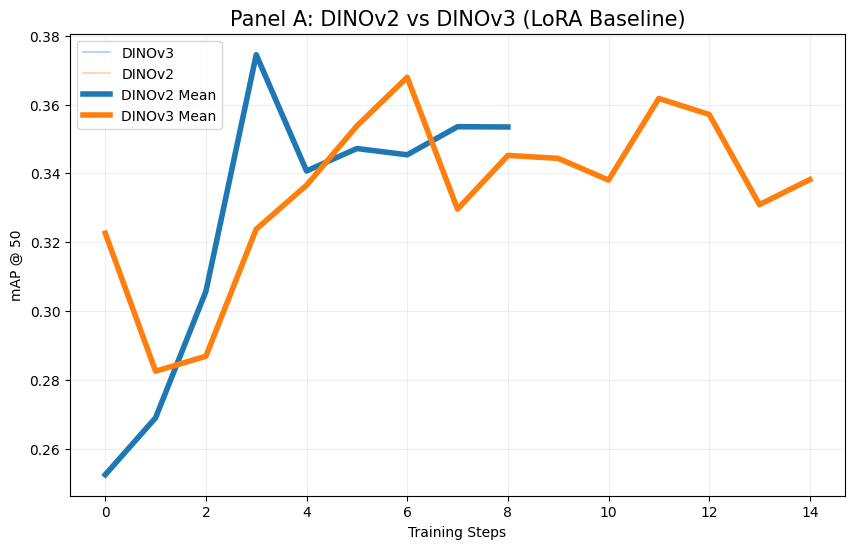

In [14]:
# 1. Create the 'Model' column by checking the run names
# This assumes your run folders have 'v2' or 'v3' in the string
panel_a_df = df[df['run'].str.contains('ots', case=False)].copy()

def identify_model(run_name):
    if 'v3' in run_name.lower():
        return 'DINOv3'
    elif 'v2' in run_name.lower():
        return 'DINOv2'
    return 'Unknown'

panel_a_df['Model'] = panel_a_df['run'].apply(identify_model)
panel_a_df = panel_a_df[panel_a_df['metric'].str.contains('map50', case=False)]

# 2. Now run the plot code
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot individual trajectories
sns.lineplot(data=panel_a_df, x='step', y='value', hue='Model', 
             units='run', estimator=None, alpha=0.3, legend=True)

# Add the robust mean lines
for model, color in zip(['DINOv2', 'DINOv3'], ['#1f77b4', '#ff7f0e']):
    model_data = panel_a_df[panel_a_df['Model'] == model]
    if not model_data.empty:
        # Find the shortest run length to keep the mean 'honest'
        min_final_step = model_data.groupby('run')['step'].max().min()
        safe_mean = model_data[model_data['step'] <= min_final_step]
        
        sns.lineplot(data=safe_mean, x='step', y='value', color=color, 
                     linewidth=4, label=f'{model} Mean', ci=None)

plt.title("Panel A: DINOv2 vs DINOv3 (LoRA Baseline)", fontsize=15)
plt.ylabel("mAP @ 50")
plt.xlabel("Training Steps")
plt.grid(True, alpha=0.2)
plt.show()

In [15]:
def get_early_stop_index(series, patience=5):
    max_val = 0
    count_no_improve = 0
    for i, val in enumerate(series):
        if val > max_val:
            max_val = val
            count_no_improve = 0
        else:
            count_no_improve += 1
        
        if count_no_improve >= patience:
            return i
    return len(series)

# Apply to DINOv3
v3_data = panel_a_df[panel_a_df['Model'] == 'DINOv3'].sort_values('step')
stop_idx = get_early_stop_index(v3_data['value'].values, patience=5)
v3_trimmed = v3_data.iloc[:stop_idx + 1]

# Keep DINOv2 as is
v2_data = panel_a_df[panel_a_df['Model'] == 'DINOv2']

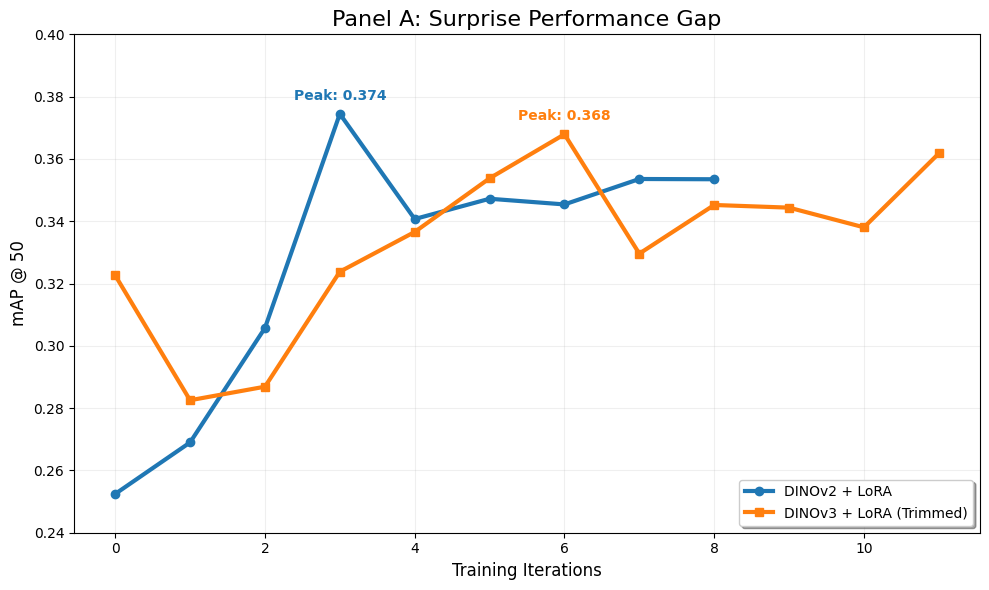

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the data
plt.plot(v2_data['step'], v2_data['value'], label='DINOv2 + LoRA', color='#1f77b4', linewidth=3, marker='o')
plt.plot(v3_trimmed['step'], v3_trimmed['value'], label='DINOv3 + LoRA (Trimmed)', color='#ff7f0e', linewidth=3, marker='s')

# Highlight Peaks
v2_peak = v2_data.loc[v2_data['value'].idxmax()]
v3_peak = v3_trimmed.loc[v3_trimmed['value'].idxmax()]

plt.annotate(f"Peak: {v2_peak['value']:.3f}", (v2_peak['step'], v2_peak['value']), 
             textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#1f77b4')
plt.annotate(f"Peak: {v3_peak['value']:.3f}", (v3_peak['step'], v3_peak['value']), 
             textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#ff7f0e')

# Poster Formatting
plt.title("Panel A: Surprise Performance Gap", fontsize=16)
plt.xlabel("Training Iterations", fontsize=12)
plt.ylabel("mAP @ 50", fontsize=12)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(alpha=0.2)
plt.ylim(0.24, 0.40) # Adjust based on your data range
plt.tight_layout()
plt.show()

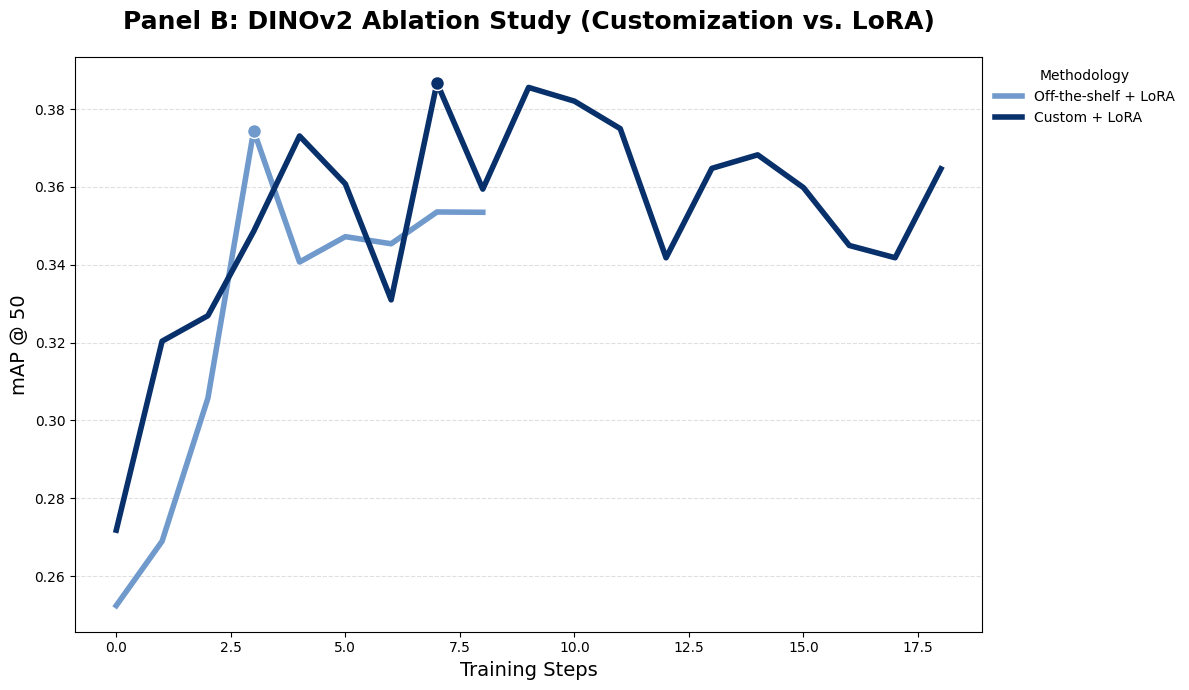

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filtering & Categorization (as per your logic)
panel_b_df = df[df['run'].str.contains('v2', case=False)].copy()
panel_b_df = panel_b_df[panel_b_df['run'].str.contains('upsample', case=False)].copy()

panel_b_df = panel_b_df[~panel_b_df['run'].str.contains('validclip|small', case=False)].copy()

panel_b_df = panel_b_df.sort_values('step')
# stop_idx = get_early_stop_index(panel_b_df['value'].values, patience=5)
# panel_b_df = panel_b_df.iloc[:stop_idx + 1]

def categorize_v2(run_name):
    run_name = run_name.lower()
    if 'peft' in run_name and 'ots' not in run_name:
        return 'Custom + LoRA'
    elif 'peft' in run_name and 'ots' in run_name:
        return 'Off-the-shelf + LoRA'
    elif 'ots' not in run_name:
        return 'Custom Backbone Baseline'
    else:
        return 'Off-the-shelf Baseline'

panel_b_df['Category'] = panel_b_df['run'].apply(categorize_v2)
panel_b_df = panel_b_df[panel_b_df['metric'].str.contains('map50', case=False)]

# 2. Apply Smoothing for Poster Clarity
# panel_b_df['smoothed_val'] = panel_b_df.groupby('Category')['value'].transform(lambda x: x.ewm(alpha=0.4).mean())

# 3. Enhanced Plotting
plt.figure(figsize=(12, 7))

# Updated Palette to handle all 4 categories with a logical "depth" of color
palette = {
    "Off-the-shelf Baseline": "#AEC7E8",       # Light Blue
    "Off-the-shelf + LoRA": "#7099CC",        # Medium Blue
    "Custom Backbone Baseline": "#1F77B4",    # Deep Blue
    "Custom + LoRA": "#08306B"                # Navy/Black-Blue
}

sns.lineplot(data=panel_b_df, x='step', y='value', hue='Category', 
             palette=palette, linewidth=4)

# Optional: Add Peak Markers
for cat in panel_b_df['Category'].unique():
    subset = panel_b_df[panel_b_df['Category'] == cat]
    peak = subset.loc[subset['value'].idxmax()]
    plt.scatter(peak['step'], peak['value'], color=palette[cat], s=100, edgecolors='white', zorder=5)

plt.title("Panel B: DINOv2 Ablation Study (Customization vs. LoRA)", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("mAP @ 50", fontsize=14)
plt.xlabel("Training Steps", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Methodology", frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [49]:

# Get the peak performance per run
run_summary = panel_b_df[panel_b_df['metric']=="mAP50"].groupby(['run'])['value'].agg(['max', 'mean', 'std']).reset_index()
print(run_summary)

                              run       max      mean       std
0  dinov2_vitl14ots_upsample_peft  0.374466  0.326888  0.041786
1     dinov2_vitl16_upsample_peft  0.386709  0.353011  0.027620


In [53]:
panel_b_df

,run,step,wall_time,metric,value,Category
581,dinov2_vitl14ots_upsample_peft,0,1.776532e+09,mAP50,0.252459,Off-the-shelf + LoRA
721,dinov2_vitl16_upsample_peft,0,1.776455e+09,mAP50,0.271828,Custom + LoRA
582,dinov2_vitl14ots_upsample_peft,1,1.776536e+09,mAP50,0.268985,Off-the-shelf + LoRA
722,dinov2_vitl16_upsample_peft,1,1.776459e+09,mAP50,0.320369,Custom + LoRA
583,dinov2_vitl14ots_upsample_peft,2,1.776540e+09,mAP50,0.305733,Off-the-shelf + LoRA
723,dinov2_vitl16_upsample_peft,2,1.776463e+09,mAP50,0.326916,Custom + LoRA
724,dinov2_vitl16_upsample_peft,3,1.776467e+09,mAP50,0.348599,Custom + LoRA
584,dinov2_vitl14ots_upsample_peft,3,1.776544e+09,mAP50,0.374466,Off-the-shelf + LoRA
585,dinov2_vitl14ots_upsample_peft,4,1.776548e+09,mAP50,0.340704,Off-the-shelf + LoRA
725,dinov2_vitl16_upsample_peft,4,1.776471e+09,mAP50,0.373078,Custom + LoRA


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for the specific comparison
panel_a_df = df[df['run'].str.contains('ots', case=False)]

# 2. Setup the plot
plt.figure(figsize=(10, 6))
# Plot individual lines (units='run' prevents averaging)
sns.lineplot(data=panel_a_df, x='step', y='value', hue='Model', 
             units='run', estimator=None, alpha=0.4, legend=False)

# 3. Add 'Mean' lines that stop when the FIRST run in that group stops
# This prevents the 'unstable tail' problem
for model in ['DINOv2', 'DINOv3']:
    model_data = panel_a_df[panel_a_df['Model'] == model]
    # Find the shortest run length for this model to keep the mean 'safe'
    min_final_step = model_data.groupby('run')['step'].max().min()
    safe_mean = model_data[model_data['step'] <= min_final_step]
    
    sns.lineplot(data=safe_mean, x='step', y='value', color='orange' if 'v3' in model else 'blue', 
                 linewidth=3, label=f'{model} (Trend)')

plt.title("Panel A: Architecture Comparison (DINOv2 vs DINOv3)", fontsize=14)
plt.ylabel("mAP @ 50")
plt.show()

ValueError: Could not interpret value `Model` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

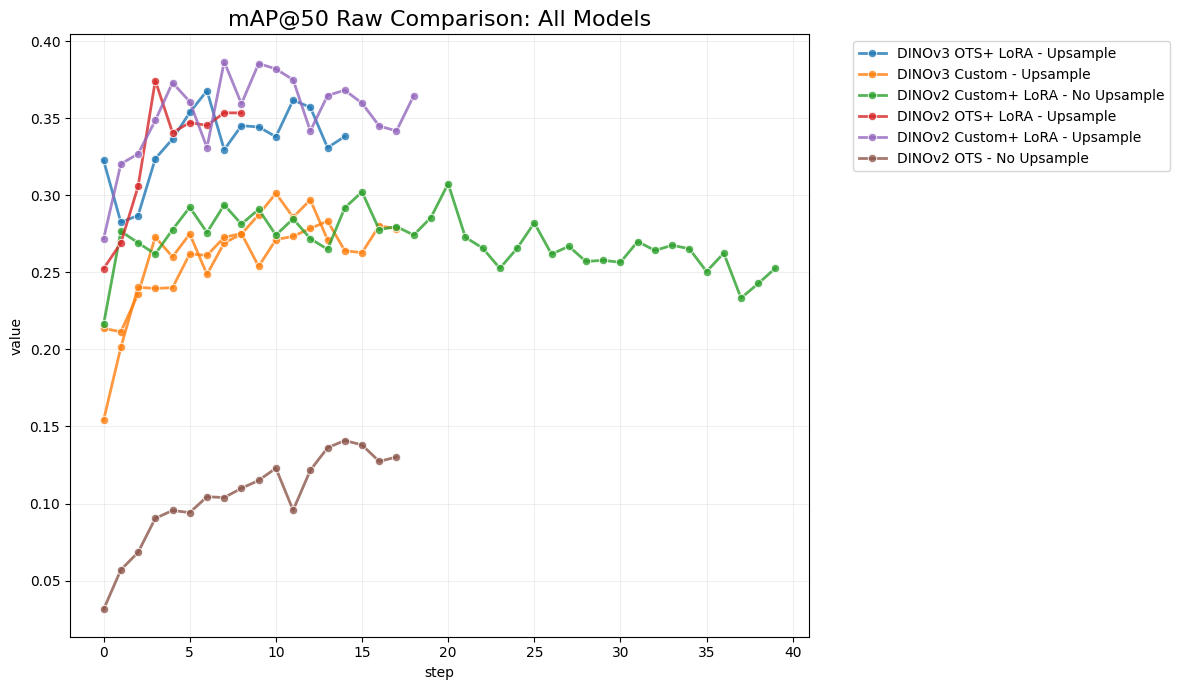

In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("/mnt/sarl_commons06/Wernke_projects/zimmejr1/prediction_eval.csv")







In [ ]:

# Use a list for the index parameter to create independent rows
error_matrix = pd.crosstab(
    index=[df["class_name"], df["eval"]], columns=df["notes"].fillna("No Error")
)

# Display the matrix
print(error_matrix)